--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

--- Missing Values Before Cleaning ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0


/tmp/ipykernel_1251/244887938.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sex', y='Survived', palette='Set1', errorbar=None, ax=axes[0, 0])
/tmp/ipykernel_1251/244887938.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', palette='muted', errorbar=None, ax=axes[0, 1])
/tmp/ipykernel_1251/244887938.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y='Age', palette='pastel', ax=axes[1, 0])
/tmp/ipykernel_1251/244887938.py:62: UserWarning: set_ticklabels() should

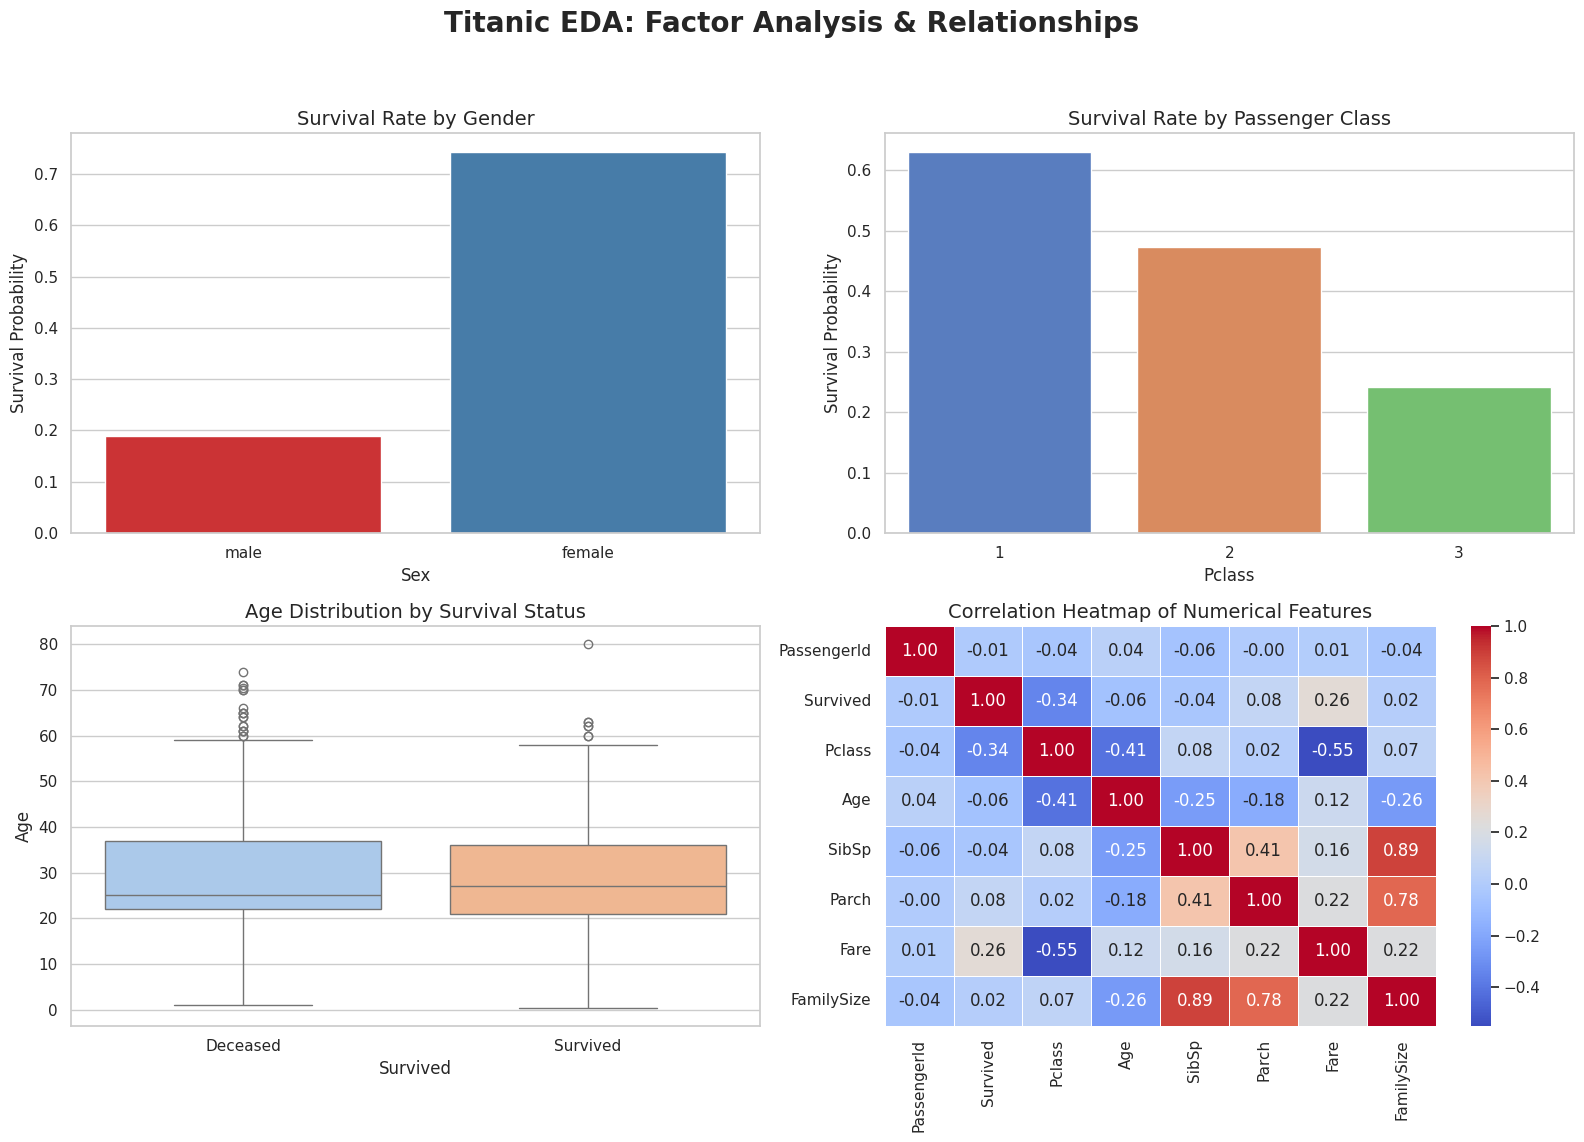

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TASK 2: Data Cleaning and Exploratory Data Analysis (EDA)
# Dataset: Titanic Passenger Data


def load_and_inspect(url):
    """Loads dataset and provides initial structural overview."""
    df = pd.read_csv(url)
    print("--- Dataset Information ---")
    print(df.info())
    print("\n--- Missing Values Before Cleaning ---")
    print(df.isnull().sum())
    return df

def clean_data(df):
    """Handles missing values, drops uninformative columns, and fixes types."""
    print("\nCleaning data...")
    df_cleaned = df.copy()

    df_cleaned['Age'] = df_cleaned.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

    df_cleaned['Embarked'] = df_cleaned['Embarked'].fillna(df_cleaned['Embarked'].mode()[0])

    df_cleaned.drop(columns=['Cabin'], inplace=True)

    df_cleaned['FamilySize'] = df_cleaned['SibSp'] + df_cleaned['Parch'] + 1

    print("Data cleaning complete. Remaining missing values:")
    print(df_cleaned.isnull().sum())
    return df_cleaned

def perform_eda(df):
    """Explores relationships, correlation patterns, and trends in the data."""
    print("\nPerforming Exploratory Data Analysis...")

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Titanic EDA: Factor Analysis & Relationships', fontsize=20, fontweight='bold')

    sns.barplot(data=df, x='Sex', y='Survived', palette='Set1', errorbar=None, ax=axes[0, 0])
    axes[0, 0].set_title('Survival Rate by Gender', fontsize=14)
    axes[0, 0].set_ylabel('Survival Probability')

    sns.barplot(data=df, x='Pclass', y='Survived', palette='muted', errorbar=None, ax=axes[0, 1])
    axes[0, 1].set_title('Survival Rate by Passenger Class', fontsize=14)
    axes[0, 1].set_ylabel('Survival Probability')

    sns.boxplot(data=df, x='Survived', y='Age', palette='pastel', ax=axes[1, 0])
    axes[1, 0].set_title('Age Distribution by Survival Status', fontsize=14)
    axes[1, 0].set_xticklabels(['Deceased', 'Survived'])

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    corr_matrix = df[numeric_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[1, 1])
    axes[1, 1].set_title('Correlation Heatmap of Numerical Features', fontsize=14)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def main():
    url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

    # Execute EDA Pipeline
    df = load_and_inspect(url)
    cleaned_df = clean_data(df)
    perform_eda(cleaned_df)

if __name__ == "__main__":
    main()